# Functional Differentiation of Beings in Near-Death Experiences

A statistical analysis of 6,751 NDE reports (2 exact duplicates removed) · **Created:** 2026-10-06

---

## Purpose

`CLAUDE.md` lists "Entity Function Differentiation" as a confirmed prediction of the Swedenborgian framework:

> Higher-order beings (God, religious figures) provide MORE significant guidance (70–73%); deceased relatives provide more comfort than guidance and serve as gatekeepers (29.5% "told to return"); χ² = 41.13, p = 0.008.

None of these figures is produced by any notebook in `projects/nde` (current or archived); the 2026-10 audit flagged the claim as unverified. The percentages appear to come from the legacy script `scripts/entity_role_analysis.py`. That script reads the pre-2026 schema (`guidance_level`, `return_choices`) from an `output/analysis/` directory that no longer exists. It reports "told to return" as a share of *all* records, not of relative encounters, and it computes no χ² test. χ² = 41.13 has no source in the repository. This notebook tests the claim on the current extraction.

## Framework prediction

Spiritual beings occupy differentiated functional roles. Concretely:

| # | Hypothesis | Test |
|---|---|---|
| H1 | Being types differ in what they do (not interchangeable projections) | Function rates across five exclusive being types; cross-validated classifier of being type from functions |
| H2 | Divine/religious figures give more guidance, especially teaching | Guidance received, teaching, life guidance: divine vs deceased relatives |
| H3 | Deceased relatives comfort more than they teach | Comfort vs teaching within relative encounters; comfort divine vs relatives |
| H4 | Deceased relatives act as gatekeepers (send the experiencer back) | Verbal limit, external return agency, "not your time", directional guidance |
| H5 | Functional signatures are consistent across contexts | Interaction with archive (NDERF/IANDS) and religious background |

## Design note — attributing a function to a being

Guidance, communication and return fields are recorded **per account**, not per being. A function can therefore be attributed to a being type only when that type is the *only* kind of being in the account. The analysis uses five mutually exclusive groups and sets aside accounts with more than one kind of being ("mixed").

## Part I: Data and being-type groups

In [1]:
import sys, json, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu, wilcoxon
from statsmodels.stats.multitest import multipletests

NDE_ROOT = Path.cwd().parent
sys.path.insert(0, str(NDE_ROOT / "scripts"))
import nde_dataset as nd  # verified loader: schema-checked fields, dedup, narrative word counts

OUTPUT_DIR = NDE_ROOT / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 8)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

df = nd.load_frame()          # one row per NDE; exact duplicate narratives removed
N = len(df)
print(f"Loaded {N:,} records (after removing exact duplicate narratives)")
print(df["dataset"].value_counts().to_string())

import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score

# Chart tokens (dataviz reference palette, light surface)
SURFACE, INK, INK2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
SLOT = {"divine": "#2a78d6", "relatives": "#eb6834", "unknown": "#1baf7a"}  # validated all-pairs (3 slots)
plt.rcParams.update({"figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": AXIS, "axes.labelcolor": INK2,
                     "xtick.color": MUTED, "ytick.color": INK2, "text.color": INK, "axes.grid": False, "font.size": 10})

Loaded 6,751 records (after removing exact duplicate narratives)
dataset
nderf    5659
iands    1092


In [2]:
DIVINE = {"god", "jesus", "buddha", "religious_figure_specified"}
for v in DIVINE | {"unknown_presence", "angels", "deceased_relative_guide", "other"}:
    nd.check_values("being_identifications", [v])
nd.check_values("deceased_relatives", ["named", "unnamed"])

ids = df["being_identifications"]
flags = pd.DataFrame({
    "divine": ids.apply(lambda s: bool(set(s) & DIVINE)),
    "unknown": ids.apply(lambda s: "unknown_presence" in s),
    "angels": ids.apply(lambda s: "angels" in s),
    "relatives": ids.apply(lambda s: "deceased_relative_guide" in s) | df["deceased_relatives"].isin(["named", "unnamed"]),
    "other": ids.apply(lambda s: "other" in s),
})
n_types = flags.sum(axis=1)
df["grp"] = np.where(n_types == 1, flags.idxmax(axis=1), np.where(n_types == 0, "no beings", "mixed"))
GROUPS = ["divine", "unknown", "angels", "relatives", "other"]
LABEL = {"divine": "Divine/religious figure only", "unknown": "Unknown presence only", "angels": "Angels only",
         "relatives": "Deceased relatives only", "other": "Other beings only"}
print("Being-type groups (mutually exclusive):")
for g, k in df["grp"].value_counts().items():
    print(f"  {g:10s} {nd.fmt_pct(int(k), N)}")
print("\nMedian narrative length (words):", df.groupby("grp")["word_count"].median().reindex(GROUPS).round(0).to_dict())

Being-type groups (mutually exclusive):
  no beings  2893/6751 = 42.9% [95% CI 41.7–44.0]
  mixed      1224/6751 = 18.1% [95% CI 17.2–19.1]
  other      910/6751 = 13.5% [95% CI 12.7–14.3]
  unknown    610/6751 = 9.0% [95% CI 8.4–9.7]
  relatives  584/6751 = 8.7% [95% CI 8.0–9.3]
  divine     418/6751 = 6.2% [95% CI 5.6–6.8]
  angels     112/6751 = 1.7% [95% CI 1.4–2.0]

Median narrative length (words): {'divine': 780.0, 'unknown': 746.0, 'angels': 684.0, 'relatives': 634.0, 'other': 646.0}


Divine/religious figure = God, Jesus, Buddha or a specified religious figure. Deceased relatives = `deceased_relative_guide` identification or deceased relatives (named/unnamed) encountered. The 1,224 mixed accounts are excluded from the comparisons because a function in them cannot be attributed to one kind of being.

---
## Part II: Function profile by being type (H1)

In [3]:
nd.check_values("guidance_types", ["teaching", "comfort", "life_guidance", "informational", "directional"])
nd.check_values("return_agency", ["external_being"]); nd.check_values("boundary_encounter", ["verbal_limit"])
nd.check_values("return_reasons", ["not_your_time"]); nd.check_values("communication_modes", ["telepathic"])
FUNCTIONS = {
    "Guidance received": lambda d: d["guidance_received"].eq("yes"),
    "Teaching": lambda d: nd.has(d, "guidance_types", "teaching"),
    "Life guidance": lambda d: nd.has(d, "guidance_types", "life_guidance"),
    "Informational guidance": lambda d: nd.has(d, "guidance_types", "informational"),
    "Comfort": lambda d: nd.has(d, "guidance_types", "comfort"),
    "Directional guidance": lambda d: nd.has(d, "guidance_types", "directional"),
    "Told it is not their time": lambda d: nd.has(d, "return_reasons", "not_your_time"),
    "Return decided by a being": lambda d: d["return_agency"].eq("external_being"),
    "Verbal limit (told to go back)": lambda d: d["boundary_encounter"].eq("verbal_limit"),
    "Telepathic communication": lambda d: nd.has(d, "communication_modes", "telepathic"),
    "Mission commissioned": lambda d: nd.isin(d, "mission_commissioned", nd.YES),
}
for name, f in FUNCTIONS.items():
    df[name] = f(df).astype(int)
FN = list(FUNCTIONS)
sub = df[df["grp"].isin(GROUPS)].copy()

rows = []
for name in FN:
    t = pd.crosstab(sub["grp"], sub[name]).reindex(GROUPS)
    chi2, p, dof, exp = chi2_contingency(t)
    rows.append({"function": name, **{g: round(100 * sub.loc[sub.grp == g, name].mean(), 1) for g in GROUPS},
                 "χ²(4)": round(chi2, 1), "p": p, "V": round(nd.cramers_v(t), 3)})
prof = pd.DataFrame(rows)
prof["p_holm"] = multipletests(prof["p"], method="holm")[1]
print("% of accounts in each group (n:", sub["grp"].value_counts().reindex(GROUPS).to_dict(), ")")
print(prof.to_string(index=False, float_format=lambda v: f"{v:.3g}"))

stated = sub[sub["guidance_received"].isin(["yes", "no"])]
print("\nGuidance received, of accounts stating yes/no:")
for g in GROUPS:
    x = stated[stated.grp == g]
    print(f"  {LABEL[g]:30s} {nd.fmt_pct(int(x.guidance_received.eq('yes').sum()), len(x))}")

% of accounts in each group (n: {'divine': 418, 'unknown': 610, 'angels': 112, 'relatives': 584, 'other': 910} )
                      function  divine  unknown  angels  relatives  other  χ²(4)        p     V   p_holm
             Guidance received    73.2     77.5    72.3       75.9   68.6   17.9  0.00128 0.082  0.00597
                      Teaching      23     17.5    20.5        4.5   13.6   81.1 1.03e-16 0.175 1.14e-15
                 Life guidance    37.1     23.8      33       27.7   22.5   36.4 2.41e-07 0.118 2.17e-06
        Informational guidance    29.9     31.5    29.5       22.8   31.5   15.7  0.00346 0.077   0.0104
                       Comfort    29.4     28.7    33.9       33.2   24.9   13.7  0.00836 0.072   0.0167
          Directional guidance    36.1     47.9    41.1         51   42.6   26.5 2.47e-05   0.1 0.000197
     Told it is not their time    30.4     28.5    25.9       37.7   28.5   18.1  0.00119 0.083  0.00597
     Return decided by a being    39.2     36.1

In [4]:
# Functional signature: can the function profile tell divine-only from relatives-only accounts?
dr = sub[sub["grp"].isin(["divine", "relatives"])]
y = dr["grp"].eq("divine").astype(int)
cv = StratifiedKFold(5, shuffle=True, random_state=0)
aucs = {}
for label, cols in [("narrative length only", ["log_words"]), ("functions + length", FN + ["log_words"])]:
    p_oof = cross_val_predict(LogisticRegression(max_iter=5000), dr[cols], y, cv=cv, method="predict_proba")[:, 1]
    aucs[label] = roc_auc_score(y, p_oof)
    if label.startswith("functions"):
        oof = pd.Series(p_oof, index=dr.index)
rng = np.random.default_rng(0)
boot = []
for _ in range(1000):
    i = rng.integers(0, len(y), len(y))
    if y.iloc[i].nunique() == 2:
        boot.append(roc_auc_score(y.iloc[i], oof.iloc[i]))
print(f"Divine vs relatives, 5-fold cross-validated AUC: length only {aucs['narrative length only']:.3f}; "
      f"functions + length {aucs['functions + length']:.3f} (95% CI {np.percentile(boot, 2.5):.3f}–{np.percentile(boot, 97.5):.3f})")

# Where do the other being types fall on the divine–relatives axis?
model = LogisticRegression(max_iter=5000).fit(dr[FN + ["log_words"]], y)
score = pd.concat([oof, pd.Series(model.predict_proba(sub.loc[~sub.index.isin(dr.index), FN + ["log_words"]])[:, 1],
                                  index=sub.index[~sub.index.isin(dr.index)])])
sub["divine_likeness"] = score
print("\nMean 'divine-likeness' score (0 = relatives-like, 1 = divine-like; out-of-fold for divine/relatives):")
for g in GROUPS:
    s = sub.loc[sub.grp == g, "divine_likeness"]
    b = [rng.choice(s.values, len(s)).mean() for _ in range(1000)]
    print(f"  {LABEL[g]:30s} {s.mean():.3f} (95% CI {np.percentile(b, 2.5):.3f}–{np.percentile(b, 97.5):.3f}), n = {len(s)}")

Divine vs relatives, 5-fold cross-validated AUC: length only 0.555; functions + length 0.673 (95% CI 0.640–0.707)

Mean 'divine-likeness' score (0 = relatives-like, 1 = divine-like; out-of-fold for divine/relatives):
  Divine/religious figure only   0.481 (95% CI 0.463–0.500), n = 418
  Unknown presence only          0.454 (95% CI 0.441–0.468), n = 610
  Angels only                    0.458 (95% CI 0.424–0.492), n = 112
  Deceased relatives only        0.370 (95% CI 0.359–0.382), n = 584
  Other beings only              0.436 (95% CI 0.425–0.447), n = 910


**Findings (H1 — supported).** Ten of eleven functions differ across the five being types after Holm correction (only the verbal-limit code does not). Effect sizes are small to moderate (Cramér's V 0.07–0.18), largest for teaching (V = 0.18). The function profile separates divine-only from relatives-only accounts better than narrative length alone (cross-validated AUC 0.673, 95% CI 0.640–0.707, vs 0.555). The separation is modest — the groups overlap — but it is not an artefact of length.

On the divine–relatives axis, unknown-presence (0.454), angel (0.458) and other-being (0.436) accounts all sit near the divine end (0.481); deceased relatives (0.370) are the distinct group. The unknown presence is functionally close to divine figures (identical telepathy rate, similar teaching, guidance and return codes), which is what "constant state, variable form" predicts — but so are angels and other beings, so the closeness is not specific to the unknown presence.

---
## Part III: Length-adjusted contrasts (H2–H4)

In [5]:
def contrast(a, b):
    d = sub[sub["grp"].isin([a, b])].assign(x=lambda t: t["grp"].eq(a).astype(int))
    out = []
    for name in FN:
        r = nd.adjusted_odds_ratio(d.assign(yy=d[name]), "yy", "x")
        out.append({"function": name, f"{a} %": round(100 * d.loc[d.x == 1, name].mean(), 1), f"{b} %": round(100 * d.loc[d.x == 0, name].mean(), 1),
                    "crude OR": round(r["crude_or"], 2), "adj OR": round(r["adj_or"], 2),
                    "adj 95% CI": f"{r['adj_ci'][0]:.2f}–{r['adj_ci'][1]:.2f}", "adj p": r["adj_p"]})
    t = pd.DataFrame(out)
    t["p_holm"] = multipletests(t["adj p"], method="holm")[1]
    return t

contrasts = {}
for a, b in [("divine", "relatives"), ("unknown", "relatives"), ("divine", "unknown")]:
    contrasts[(a, b)] = contrast(a, b)
    print(f"\n{LABEL[a]} vs {LABEL[b]} (odds ratios adjusted for log word count; Holm across the 11 functions)")
    print(contrasts[(a, b)].to_string(index=False, float_format=lambda v: f"{v:.3g}"))


Divine/religious figure only vs Deceased relatives only (odds ratios adjusted for log word count; Holm across the 11 functions)
                      function  divine %  relatives %  crude OR  adj OR adj 95% CI    adj p   p_holm
             Guidance received      73.2         75.9      0.87    0.81  0.61–1.09    0.162    0.163
                      Teaching        23          4.5       6.4    6.27  3.94–9.98 9.94e-15 1.09e-13
                 Life guidance      37.1         27.7      1.54    1.43  1.09–1.88   0.0107   0.0752
        Informational guidance      29.9         22.8      1.45    1.39  1.05–1.86   0.0232    0.116
                       Comfort      29.4         33.2      0.84    0.76  0.57–1.00   0.0534     0.16
          Directional guidance      36.1           51      0.54    0.54  0.42–0.70 3.54e-06 3.54e-05
     Told it is not their time      30.4         37.7      0.72    0.72  0.55–0.95   0.0187    0.112
     Return decided by a being      39.2         46.7      0.74


Unknown presence only vs Deceased relatives only (odds ratios adjusted for log word count; Holm across the 11 functions)
                      function  unknown %  relatives %  crude OR  adj OR adj 95% CI    adj p   p_holm
             Guidance received       77.5         75.9       1.1    1.06  0.81–1.39    0.655    0.815
                      Teaching       17.5          4.5      4.57    4.47  2.84–7.03 9.32e-11 1.03e-09
                 Life guidance       23.8         27.7      0.81    0.76  0.58–0.99   0.0426    0.213
        Informational guidance       31.5         22.8      1.56    1.52  1.17–1.97  0.00167   0.0117
                       Comfort       28.7         33.2      0.81    0.75  0.58–0.97   0.0263    0.158
          Directional guidance       47.9           51      0.88    0.88  0.70–1.11    0.272    0.815
     Told it is not their time       28.5         37.7      0.66    0.67  0.52–0.85  0.00108  0.00866
     Return decided by a being       36.1         46.7      0.


Divine/religious figure only vs Unknown presence only (odds ratios adjusted for log word count; Holm across the 11 functions)
                      function  divine %  unknown %  crude OR  adj OR adj 95% CI    adj p   p_holm
             Guidance received      73.2       77.5      0.79    0.77  0.58–1.04   0.0843     0.59
                      Teaching        23       17.5       1.4    1.39  1.01–1.91   0.0415    0.332
                 Life guidance      37.1       23.8      1.89    1.89  1.43–2.49 6.81e-06 7.49e-05
        Informational guidance      29.9       31.5      0.93    0.92  0.70–1.21     0.54        1
                       Comfort      29.4       28.7      1.04    1.01  0.77–1.34    0.929        1
          Directional guidance      36.1       47.9      0.62    0.61  0.48–0.79  0.00018   0.0018
     Told it is not their time      30.4       28.5      1.09    1.09  0.83–1.44    0.516        1
     Return decided by a being      39.2       36.1      1.14    1.15  0.89–1.48 

In [6]:
# H3: within relative encounters, is comfort more common than teaching / guidance?
rel = sub[sub.grp == "relatives"]
with_types = rel[rel["guidance_types"].apply(len) > 0]
print(f"Deceased-relatives-only accounts with any guidance type: n = {len(with_types)}")
for t in ["directional", "comfort", "informational", "life_guidance", "teaching"]:
    print(f"  {t:15s} {nd.fmt_pct(int(nd.has(with_types, 'guidance_types', t).sum()), len(with_types))}")
both = pd.crosstab(nd.has(rel, "guidance_types", "comfort"), nd.has(rel, "guidance_types", "teaching"))
print("McNemar comfort vs teaching (paired within relative accounts):", mcnemar_result := stats.binomtest(int(both.loc[True, False]), int(both.loc[True, False] + both.loc[False, True])).pvalue)
both2 = pd.crosstab(nd.has(rel, "guidance_types", "comfort"), nd.has(rel, "guidance_types", "life_guidance"))
print("Exact McNemar comfort vs life guidance:", stats.binomtest(int(both2.loc[True, False]), int(both2.loc[True, False] + both2.loc[False, True])).pvalue)

# H4: gatekeeping composite — told to go back in any of the three ways
sub["sent_back"] = (sub["Told it is not their time"] | sub["Return decided by a being"] | sub["Verbal limit (told to go back)"]).astype(int)
for g in GROUPS:
    print(f"  sent back (any of 3 codes) — {LABEL[g]:30s} {nd.fmt_pct(int(sub.loc[sub.grp == g, 'sent_back'].sum()), int((sub.grp == g).sum()))}")
d = sub[sub.grp.isin(["divine", "relatives"])].assign(x=lambda t: t.grp.eq("relatives").astype(int))
r = nd.adjusted_odds_ratio(d.assign(yy=d.sent_back), "yy", "x")
print(f"Relatives vs divine, sent back: crude OR {r['crude_or']:.2f}; length-adjusted OR {r['adj_or']:.2f} ({r['adj_ci'][0]:.2f}–{r['adj_ci'][1]:.2f}), p = {r['adj_p']:.2g}")

Deceased-relatives-only accounts with any guidance type: n = 443
  directional     298/443 = 67.3% [95% CI 62.8–71.5]
  comfort         194/443 = 43.8% [95% CI 39.2–48.4]
  informational   133/443 = 30.0% [95% CI 25.9–34.4]
  life_guidance   162/443 = 36.6% [95% CI 32.2–41.2]
  teaching        26/443 = 5.9% [95% CI 4.0–8.5]
McNemar comfort vs teaching (paired within relative accounts): 1.2951769392733184e-41
Exact McNemar comfort vs life guidance: 0.027336775277083523
  sent back (any of 3 codes) — Divine/religious figure only   216/418 = 51.7% [95% CI 46.9–56.4]
  sent back (any of 3 codes) — Unknown presence only          298/610 = 48.9% [95% CI 44.9–52.8]
  sent back (any of 3 codes) — Angels only                    53/112 = 47.3% [95% CI 38.3–56.5]
  sent back (any of 3 codes) — Deceased relatives only        319/584 = 54.6% [95% CI 50.6–58.6]
  sent back (any of 3 codes) — Other beings only              428/910 = 47.0% [95% CI 43.8–50.3]
Relatives vs divine, sent back: crude OR 1.

**Findings (H2–H4).** Read against the claim in `CLAUDE.md` (all odds ratios adjusted for narrative length; Holm across 11 functions):

- *H2 — supported for teaching, not for guidance overall.* Divine figures do **not** give more guidance overall (73.2% vs 75.9%; adjusted OR 0.81, 0.61–1.09). They give a different **kind** of guidance and contact: teaching 23.0% vs 4.5% (OR 6.27, 3.94–9.98), telepathic communication 44.0% vs 28.6% (OR 1.83), mission commissioning 35.4% vs 24.0% (OR 1.62). Life guidance is higher (OR 1.43) but not after Holm correction. "More significant guidance (70–73%)" is not reproducible; "more teaching" is, strongly.
- *H3 — supported as "comfort rather than teaching".* Within relative encounters with guidance, directional guidance (67.3%) and comfort (43.8%) dominate and teaching is rare (5.9%; comfort vs teaching paired p < 10⁻⁴⁰). Relatives do not comfort significantly more than divine figures do (33.2% vs 29.4%; OR 0.76, 0.57–1.00, Holm p = 0.16). Relatives give significantly more directional guidance (51.0% vs 36.1%; OR 0.54 for divine, Holm p < 0.001).
- *H4 — weak.* Relatives-only accounts are somewhat more often told it is not their time (37.7% vs 30.4%) and have the return decided by a being (46.7% vs 39.2%), but neither survives Holm correction against divine figures (Holm p = 0.11 and 0.12), the verbal-limit code does not differ, and a composite "sent back in any of the three ways" is 54.6% vs 51.7% (OR 1.11, 0.86–1.43, p = 0.42). Against unknown-presence accounts the two return codes do differ after correction (OR 0.67 and 0.65). Gatekeeping is shared by all being types (47–55% of accounts) rather than specific to relatives. The "29.5% told to return" figure is not reproducible from any current field.

---
## Part IV: Consistency across contexts (H5)

In [7]:
d = sub[sub.grp.isin(["divine", "relatives"])].assign(x=lambda t: t.grp.eq("divine").astype(int),
                                                       iands=lambda t: t.dataset.eq("iands").astype(int))
rel_known = d[d.religious_background.isin(["christian", "atheist_agnostic", "spiritual_not_religious", "jewish", "muslim", "hindu", "buddhist", "other"])].assign(
    christian=lambda t: t.religious_background.eq("christian").astype(int))
print(f"Divine/relatives accounts: NDERF {int((d.iands == 0).sum())}, IANDS {int(d.iands.sum())}; religion stated {len(rel_known)} (Christian {int(rel_known.christian.sum())})")
rows = []
for name in FN:
    out = {"function": name}
    for label, data, mod in [("NDERF", d[d.iands == 0], None), ("IANDS", d[d.iands == 1], None)]:
        try:
            m = smf.logit(f"Q('{name}') ~ x + log_words", data).fit(disp=0)
            out[f"adj OR {label}"] = round(float(np.exp(m.params["x"])), 2)
        except Exception:
            out[f"adj OR {label}"] = np.nan
    try:
        m = smf.logit(f"Q('{name}') ~ x * iands + log_words", d).fit(disp=0)
        out["archive interaction p"] = m.pvalues["x:iands"]
    except Exception:
        out["archive interaction p"] = np.nan
    try:
        m = smf.logit(f"Q('{name}') ~ x * christian + log_words", rel_known).fit(disp=0)
        out["religion interaction p"] = m.pvalues["x:christian"]
    except Exception:
        out["religion interaction p"] = np.nan
    rows.append(out)
cons = pd.DataFrame(rows)
cons["archive p_holm"] = multipletests(cons["archive interaction p"].fillna(1), method="holm")[1]
cons["religion p_holm"] = multipletests(cons["religion interaction p"].fillna(1), method="holm")[1]
print(cons.to_string(index=False, float_format=lambda v: f"{v:.3g}"))
same_sign = int((np.sign(np.log(cons["adj OR NDERF"])) == np.sign(np.log(cons["adj OR IANDS"]))).sum())
print(f"\nDirection of the divine-vs-relatives difference agrees between archives for {same_sign} of {len(cons)} functions")

Divine/relatives accounts: NDERF 831, IANDS 171; religion stated 241 (Christian 203)


                      function  adj OR NDERF  adj OR IANDS  archive interaction p  religion interaction p  archive p_holm  religion p_holm
             Guidance received          0.82          0.74                   0.72                   0.882               1                1
                      Teaching           5.9          8.46                  0.581                   0.479               1                1
                 Life guidance          1.28          2.38                  0.109                   0.482               1                1
        Informational guidance           1.5          0.96                  0.195                  0.0278               1            0.305
                       Comfort          0.67          1.15                  0.128                   0.752               1                1
          Directional guidance          0.57          0.42                  0.347                   0.874               1                1
     Told it is not their t

**Findings (H5 — consistent where testable).** The direction of the divine–relatives difference is the same in both archives for 9 of 11 functions, including all four that are significant overall (teaching OR 5.9 in NDERF and 8.5 in IANDS). No archive or religion interaction survives Holm correction. The tests have limited power: IANDS contributes 171 divine/relatives accounts, and only 241 state a religion (203 Christian), so "no significant interaction" is weaker evidence than the agreement in direction. Cross-cultural consistency beyond Christian vs other stated backgrounds cannot be assessed.

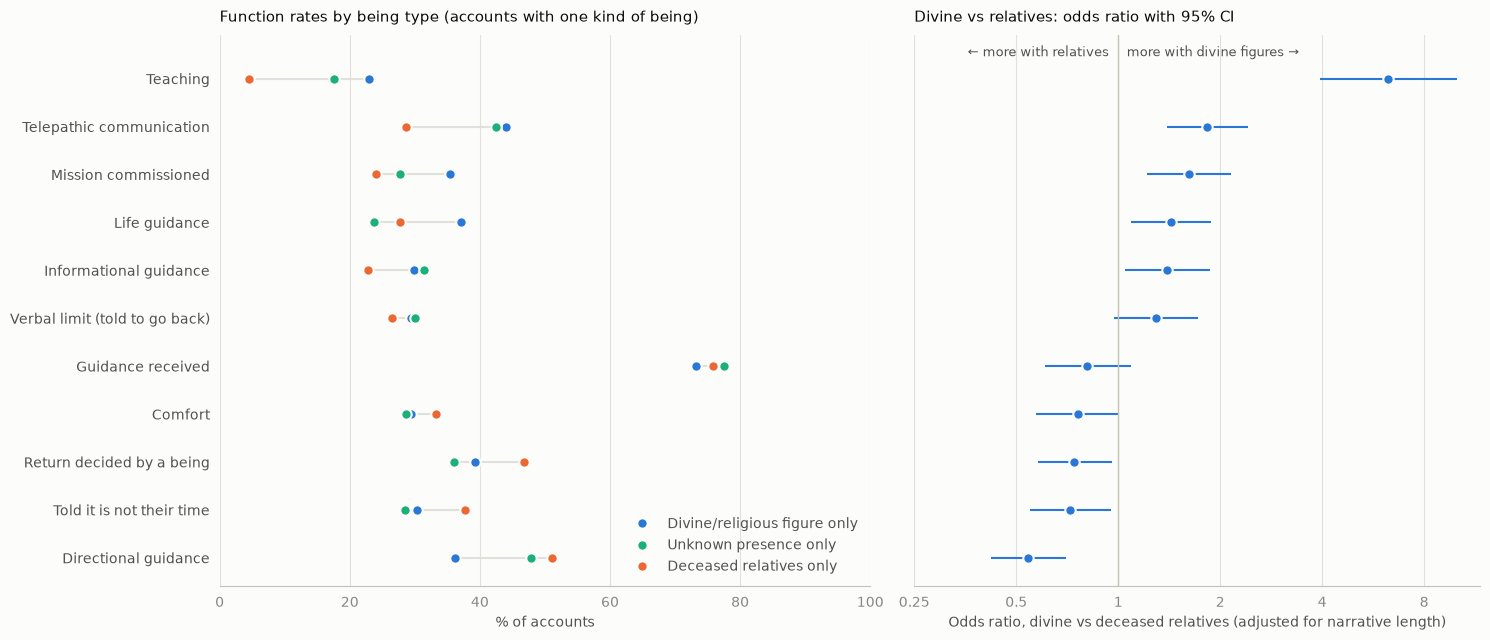

In [8]:
# Figure: function rates for the three largest being types, and length-adjusted divine-vs-relatives odds ratios
show = ["divine", "unknown", "relatives"]
order = contrasts[("divine", "relatives")].sort_values("adj OR")["function"].tolist()
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), gridspec_kw={"width_ratios": [1.15, 1]})
ax = axes[0]
ypos = np.arange(len(order))
for g in show:
    vals = [100 * sub.loc[sub.grp == g, f].mean() for f in order]
    ax.plot(vals, ypos, "o", ms=7.5, color=SLOT[g], mec=SURFACE, mew=1.5, label=LABEL[g], zorder=3)
for i, f in enumerate(order):
    v = [100 * sub.loc[sub.grp == g, f].mean() for g in show]
    ax.plot([min(v), max(v)], [i, i], color=GRID, lw=1.5, zorder=1)
ax.set_yticks(ypos, order); ax.set_xlabel("% of accounts"); ax.set_xlim(0, 100)
ax.xaxis.grid(True, color=GRID, lw=0.8); ax.set_axisbelow(True)
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)
ax.legend(loc="lower right", frameon=False, labelcolor=INK2)
ax.set_title("Function rates by being type (accounts with one kind of being)", loc="left", color=INK, fontsize=11, pad=10)

ax = axes[1]
t = contrasts[("divine", "relatives")].set_index("function").loc[order]
lo = t["adj 95% CI"].str.split("–").str[0].astype(float); hi = t["adj 95% CI"].str.split("–").str[1].astype(float)
ax.hlines(ypos, lo, hi, color=SLOT["divine"], lw=1.5)
ax.plot(t["adj OR"], ypos, "o", ms=7.5, color=SLOT["divine"], mec=SURFACE, mew=1.5)
ax.axvline(1, color=AXIS, lw=1)
ax.set_xscale("log"); ax.set_xticks([0.25, 0.5, 1, 2, 4, 8]); ax.set_xticklabels(["0.25", "0.5", "1", "2", "4", "8"])
ax.set_yticks(ypos, [""] * len(order)); ax.xaxis.grid(True, color=GRID, lw=0.8); ax.set_axisbelow(True)
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)
ax.set_xlabel("Odds ratio, divine vs deceased relatives (adjusted for narrative length)")
ax.set_ylim(-0.6, len(order) - 0.1)
ax.text(1.06, len(order) - 0.45, "more with divine figures →", color=INK2, fontsize=9, va="center")
ax.text(0.94, len(order) - 0.45, "← more with relatives", color=INK2, fontsize=9, ha="right", va="center")
axes[0].set_ylim(-0.6, len(order) - 0.1)
ax.set_title("Divine vs relatives: odds ratio with 95% CI", loc="left", color=INK, fontsize=11, pad=10)
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "07_entity_functions.png", dpi=150, bbox_inches="tight"); plt.show()

---
## Part V: Summary

See the report `reports/Functional Differentiation of Beings in NDE - Testing Role Specialisation.md` for the full write-up. The summary table is printed below from the computed results.

In [9]:
dr_t = contrasts[("divine", "relatives")].set_index("function")
def line(f):
    r = dr_t.loc[f]
    return f"{r['divine %']}% vs {r['relatives %']}%, adj OR {r['adj OR']} ({r['adj 95% CI']}), Holm p = {r['p_holm']:.2g}"
print("H1 functional signature AUC:", round(aucs["functions + length"], 3), "vs length only", round(aucs["narrative length only"], 3))
for f in ["Guidance received", "Teaching", "Life guidance", "Telepathic communication", "Mission commissioned", "Comfort",
          "Directional guidance", "Told it is not their time", "Return decided by a being", "Verbal limit (told to go back)"]:
    print(f"  {f:32s} {line(f)}")

H1 functional signature AUC: 0.673 vs length only 0.555
  Guidance received                73.2% vs 75.9%, adj OR 0.81 (0.61–1.09), Holm p = 0.16
  Teaching                         23.0% vs 4.5%, adj OR 6.27 (3.94–9.98), Holm p = 1.1e-13
  Life guidance                    37.1% vs 27.7%, adj OR 1.43 (1.09–1.88), Holm p = 0.075
  Telepathic communication         44.0% vs 28.6%, adj OR 1.83 (1.39–2.41), Holm p = 0.00013
  Mission commissioned             35.4% vs 24.0%, adj OR 1.62 (1.22–2.15), Holm p = 0.0066
  Comfort                          29.4% vs 33.2%, adj OR 0.76 (0.57–1.00), Holm p = 0.16
  Directional guidance             36.1% vs 51.0%, adj OR 0.54 (0.42–0.70), Holm p = 3.5e-05
  Told it is not their time        30.4% vs 37.7%, adj OR 0.72 (0.55–0.95), Holm p = 0.11
  Return decided by a being        39.2% vs 46.7%, adj OR 0.74 (0.58–0.96), Holm p = 0.12
  Verbal limit (told to go back)   29.4% vs 26.5%, adj OR 1.29 (0.97–1.72), Holm p = 0.16
